# Student Dropout Prediction

This notebook explores the use of machine learning techniques to predict whether a university student will drop out or successfully graduate based on demographic and academic indicators.

The analysis follows a structured data science workflow consisting of:

1. Data Understanding
2. Exploratory Data Analysis
3. Data Preparation
4. Model Training
5. Model Evaluation

## 1. Import Libraries

In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import cross_val_score
sns.set(style="whitegrid")

## 2. Load Dataset

The dataset used in this project contains demographic, academic, and socio-economic indicators describing university students. The goal is to predict whether a student will drop out or successfully graduate.

In [23]:
df = pd.read_csv("../datasets/data.csv", sep=";")

# Clean column names
df.columns = df.columns.str.replace("\t", "")
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace("'", "")

df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mothers qualification,Fathers qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 3. Dataset Overview

Before building machine learning models, it is important to understand the structure of the dataset.

### Shape

In [24]:
df.shape

(4424, 37)

### Column Names

In [25]:
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mothers qualification', 'Fathers qualification', 'Mothers occupation',
       'Fathers occupation', 'Admission grade', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)'

### Data Types

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mothers qualification                           4424 non-null   int64  
 9   Fathers qualification                           4424

## 4. Target Variable Distribution

The dataset contains three possible outcomes:

- Dropout
- Enrolled
- Graduate

Since the final outcome of "Enrolled" students is unknown, these observations will later be removed from the dataset.

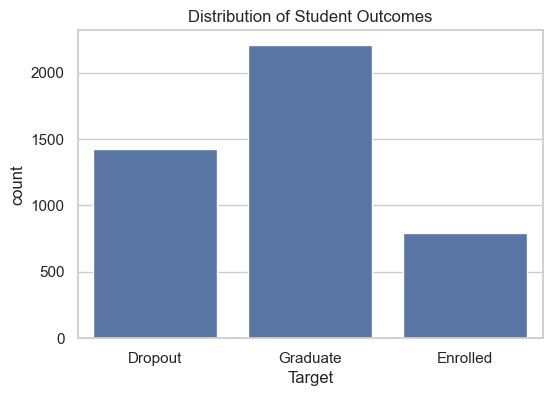

In [27]:
df["Target"].value_counts()

plt.figure(figsize=(6,4))
sns.countplot(x="Target", data=df)
plt.title("Distribution of Student Outcomes")
plt.show()

## 5. Filtering the Dataset

The "Enrolled" category represents students whose final academic outcome is not yet determined. To avoid label uncertainty, these observations are removed from the dataset.

The prediction task therefore becomes a binary classification problem:

1 = Dropout  
0 = Graduate

In [28]:
# Remove whitespace
df["Target"] = df["Target"].str.strip()

df = df[df["Target"] != "Enrolled"]

In [29]:
df["Target"].value_counts()

Target
Graduate    2209
Dropout     1421
Name: count, dtype: int64

### Convert Target to Binary

In [30]:
df["Target"] = df["Target"].map({
    "Dropout": 1,
    "Graduate": 0
})

df["Target"].value_counts()

Target
0    2209
1    1421
Name: count, dtype: int64

In [31]:
print(df["Target"].unique())

[1 0]


## 6. Exploratory Data Analysis

Before training machine learning models, exploratory data analysis is conducted to better understand relationships between variables and identify potential predictors of student dropout.

### Correlation Heatmap

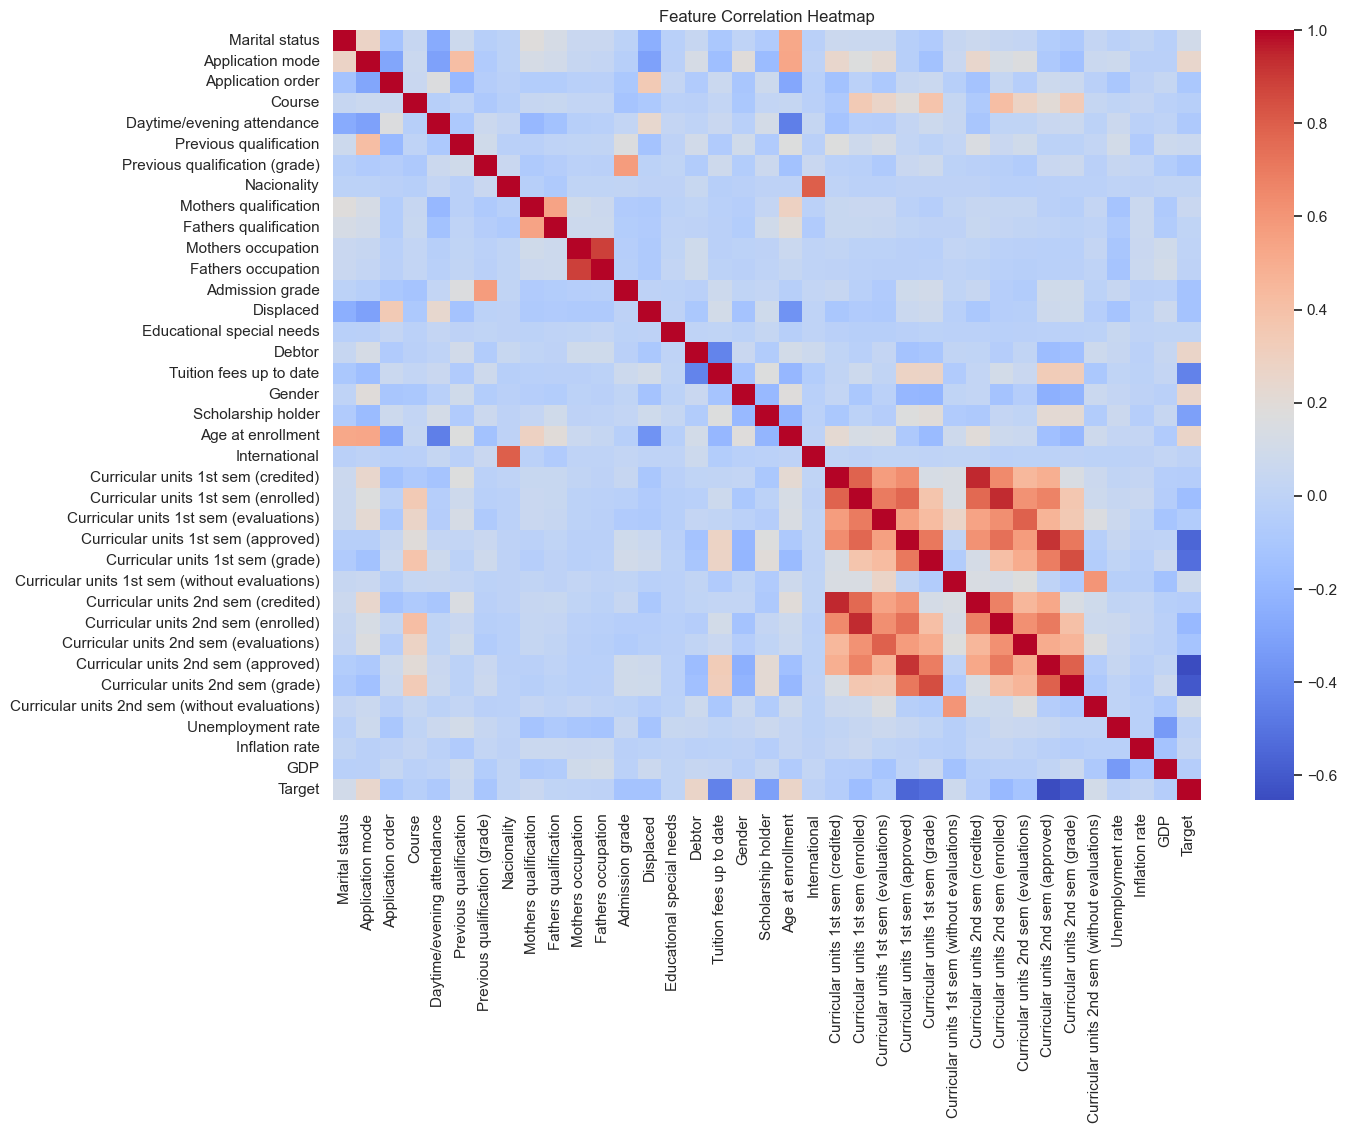

In [32]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

In [33]:
df.corr()["Target"].drop("Target").sort_values(ascending=False)

Age at enrollment                                 0.267229
Debtor                                            0.267207
Gender                                            0.251955
Application mode                                  0.244507
Curricular units 2nd sem (without evaluations)    0.102687
Marital status                                    0.100479
Curricular units 1st sem (without evaluations)    0.074642
Previous qualification                            0.062323
Mothers qualification                             0.053989
Inflation rate                                    0.030326
Nacionality                                       0.015516
Educational special needs                         0.007254
Fathers qualification                             0.005865
Mothers occupation                               -0.000772
Unemployment rate                                -0.004198
Fathers occupation                               -0.005066
International                                    -0.0061

### Interpretation

The correlation analysis shows that several academic performance indicators have a relatively strong relationship with the target variable. In particular, variables such as the `number of approved curricular units` and `course grades` show the strongest **negative** correlations with student dropout.

The negative correlations indicate that students who successfully complete more courses and achieve higher grades are less likely to drop out of their academic program. This aligns with expectations, as academic performance is often an important factor in student persistence.

Other variables, including `demographic characteristics` and `macroeconomic indicators`, show relatively **weak** correlations with the target variable. This suggests that these features may have a smaller individual influence on student dropout.

It is also important to note that several second-semester academic indicators show strong correlations with the target variable. However, since the objective of this project is to predict dropout risk early in a student's academic journey, features related to the second semester may introduce `data leakage` and will be considered carefully during the feature selection stage.

Although second-semester variables show strong correlations with the target variable, they are excluded from model training because they would introduce data leakage. These variables would not be available when making early predictions after the first semester.

## 7. Data Preparation

Before training machine learning models, the dataset must be prepared. This stage includes removing variables that may introduce data leakage, separating the feature variables from the target variable, and splitting the dataset into training and testing sets.

Since the objective of this project is to predict student dropout early in the academic journey, features related to the second semester will be removed to ensure that the model only uses information that would realistically be available at the time of prediction.

### Remove Second Semester Features

In [34]:
# Remove second semester features to avoid data leakage

df = df.drop(columns=[
  "Curricular units 2nd sem (credited)",
  "Curricular units 2nd sem (enrolled)",
  "Curricular units 2nd sem (evaluations)",
  "Curricular units 2nd sem (approved)",
  "Curricular units 2nd sem (grade)",
  "Curricular units 2nd sem (without evaluations)"
])

df.shape

(3630, 31)

### Define Features and Target

In [35]:
# Separate features and target

X = df.drop("Target", axis=1)
y = df["Target"]

print(X.shape)
print(y.shape)

(3630, 30)
(3630,)


### Train/Test Split

In [36]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (2904, 30)
Test set: (726, 30)


### Scale the Data

In [37]:
# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply same transformation to test data
X_test_scaled = scaler.transform(X_test)

# 8. Model Experiments

## 8.1. Baseline Model — Logistic Regression

The first model implemented in this analysis is `Logistic Regression`. Logistic Regression is commonly used for binary classification problems and provides a simple and interpretable baseline for evaluating predictive performance.

The goal of this step is to establish an initial benchmark that can later be compared with more complex machine learning models such as **Random Forest** and **Gradient Boosting**.

### 8.1.1. Train the Model

In [38]:
# Initialize the model
log_model = LogisticRegression(max_iter=1000)

# Train the model
log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### 8.1.2. Make Predictions

In [39]:
# Predict on the test set
y_pred = log_model.predict(X_test_scaled)

### 8.1.3. Evaluate the Model

In [40]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8953168044077136
Precision: 0.8714285714285714
Recall: 0.8591549295774648
F1 Score: 0.8652482269503546


### 8.1.4. Confusion Matrix

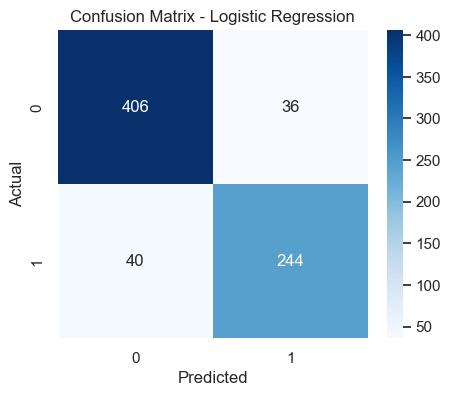

In [41]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

### 8.1.5. Model Performance Interpretation

The `Logistic Regression` model achieved an accuracy of approximately **89.5%**, indicating that the majority of student outcomes were correctly classified. This result indicates that a relatively simple linear model is able to capture much of the relationship between the predictors and student dropout.

The confusion matrix shows that the model correctly predicted **406** students who graduated and **244** students who dropped out. However, **36** students were incorrectly predicted as dropouts, while **40** dropout cases were incorrectly classified as graduates.

The recall score of **0.86** indicates that the model successfully identifies approximately **86%** of students who eventually drop out. This is particularly important in the context of early intervention systems, where detecting at-risk students is a key objective.

Overall, the `Logistic Regression` model provides a strong baseline performance that will serve as a reference when evaluating more advanced models in the following sections.

## 8.2. Random Forest Model

`Random Forest` is an ensemble learning algorithm that builds multiple decision trees and aggregates their predictions. It is capable of capturing non-linear relationships between variables and often performs well on tabular datasets.

### 8.2.1 Train the Model

In [42]:
# Initialize the model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### 8.2.2. Cross-Validation

Cross-validation is used to evaluate how well the model generalizes to unseen data by training and validating the model across multiple splits of the dataset.

In [43]:
cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("Cross-validation F1 scores:", cv_scores)
print("Average CV F1:", cv_scores.mean())

Cross-validation F1 scores: [0.83870968 0.83140878 0.82742317 0.84235294 0.85579196]
Average CV F1: 0.8391373049201981


### 8.2.3. Make Predictions

In [44]:
# Predict on the test set
rf_pred = rf_model.predict(X_test)

### 8.2.4. Evaluate the Model

In [45]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)

Accuracy: 0.8980716253443526
Precision: 0.8832116788321168
Recall: 0.852112676056338
F1 Score: 0.8673835125448028


### 8.2.5. Confusion Matrix

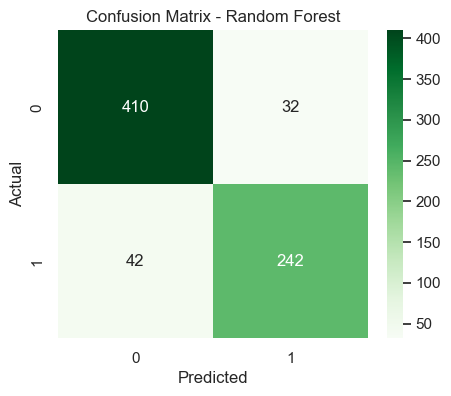

In [46]:
rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

### 8.2.6. Feature Importance

In [47]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importances.head(10))

Curricular units 1st sem (approved)       0.236320
Curricular units 1st sem (grade)          0.144950
Tuition fees up to date                   0.077774
Age at enrollment                         0.048746
Curricular units 1st sem (evaluations)    0.044851
Admission grade                           0.041632
Previous qualification (grade)            0.038863
Course                                    0.037286
Scholarship holder                        0.034298
Curricular units 1st sem (enrolled)       0.029695
dtype: float64


_The high importance of first-semester approved curricular units suggests that early academic performance plays a dominant role in predicting student dropout risk._

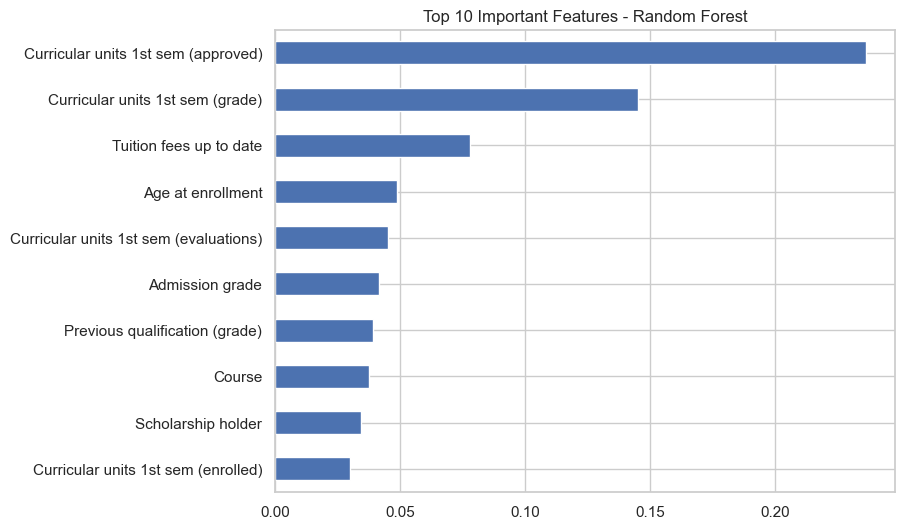

In [48]:
plt.figure(figsize=(8,6))
importances.head(10).plot(kind="barh")

plt.title("Top 10 Important Features - Random Forest")

plt.gca().invert_yaxis()

plt.show()

### 8.2.7. Model Performance Interpretation

The `Random Forest` model achieved an accuracy of approximately **89.8%**, which is slightly higher than the `Logistic Regression baseline`. The model also achieved a precision score of **0.88**, a recall score of **0.85**, and an F1-score of **0.87**.

The confusion matrix shows that the model correctly classified **410** students who graduated and **242** students who dropped out. However, **42** dropout cases were incorrectly predicted as graduates, while **32** graduates were incorrectly classified as dropouts.

The recall score of **0.85** indicates that the model successfully identifies approximately **85%** of students who eventually drop out. This performance is comparable to the Logistic Regression model, suggesting that the relationships between the variables and the target outcome may be relatively `linear`.

The cross-validation results show relatively stable F1 scores across the five folds, with an average F1-score of approximately **0.84**. This indicates that the Random Forest model generalizes well to unseen data and does not appear to suffer from significant overfitting.

Feature importance analysis reveals that first-semester academic performance indicators are the strongest predictors of student dropout. In particular, the number of approved curricular units and first-semester grades appear to have the greatest influence on the model’s predictions. These findings align with the domain research, which suggests that early academic performance is a strong indicator of student persistence.

Overall, the `Random Forest` model provides a slight improvement over the Logistic Regression baseline while offering additional insights into the relative importance of different features.

## 8.3. Gradient Boosting

Gradient Boosting is an ensemble learning algorithm that builds models sequentially, where each new model attempts to correct the errors made by the previous ones. Unlike `Random Forest`, which builds trees independently, `Gradient Boosting` improves predictions iteratively and often achieves strong performance on structured tabular datasets.

### 8.3.1 Train the Model

In [ ]:
# Initialize the model
gb_model = GradientBoostingClassifier(
  n_estimators=200, #number of trees
  learning_rate=0.05, #how much each tree contributes to the final prediction
  random_state=42 #reproducibility
)

# Train the model
gb_model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

### 8.3.2 Make Predictions

In [50]:
# Predict on the test set
gb_pred = gb_model.predict(X_test)

### 8.3.3 Evaluate the Model

In [51]:
gb_accuracy = accuracy_score(y_test, gb_pred)
gb_precision = precision_score(y_test, gb_pred)
gb_recall = recall_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)

print("Accuracy:", gb_accuracy)
print("Precision:", gb_precision)
print("Recall:", gb_recall)
print("F1 Score:", gb_f1)

Accuracy: 0.8966942148760331
Precision: 0.8772563176895307
Recall: 0.8556338028169014
F1 Score: 0.8663101604278075


### 8.3.4 Confusion Matrix

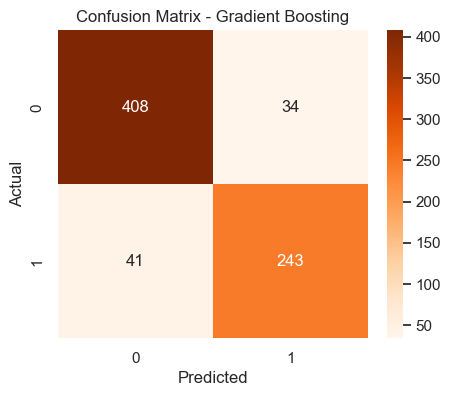

In [52]:
gb_cm = confusion_matrix(y_test, gb_pred)

plt.figure(figsize=(5,4))
sns.heatmap(gb_cm, annot=True, fmt="d", cmap="Oranges")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Gradient Boosting")

plt.show()

### 8.3.5 Model Performance Interpretation

The `Gradient Boosting` model achieved an accuracy of approximately **89.7%**, with a precision score of **0.88**, a recall score of **0.86**, and an F1-score of **0.87**. These results indicate that the model performs comparably to both the Logistic Regression and Random Forest models.

The confusion matrix shows that the model correctly classified **408** students who graduated and **243** students who dropped out. However, **41** dropout cases were incorrectly predicted as graduates, while **34** graduates were incorrectly classified as dropouts.

The recall score of 0.86 indicates that the model successfully identifies approximately **86%** of students who eventually drop out. Since the primary objective of this predictive system is early detection of at-risk students, recall remains an important metric for evaluating model effectiveness.

Compared with the other models tested in this analysis, the `Gradient Boosting` model performs very similarly. This suggests that the relationships between the predictors and student dropout risk may be relatively well captured by both linear and ensemble methods.

Overall, the `Gradient Boosting` model provides strong predictive performance while maintaining balanced precision and recall, making it a competitive candidate for predicting student dropout risk.

# 9. Model Comparison

In this section, the performance of the different machine learning models is compared using the evaluation metrics calculated earlier. The goal is to determine which model provides the most reliable predictions for identifying students at risk of dropping out.

## 9.1. Comparison Table

In [53]:
results = pd.DataFrame({
  "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
  "Accuracy": [accuracy, rf_accuracy, gb_accuracy],
  "Precision": [precision, rf_precision, gb_precision],
  "Recall": [recall, rf_recall, gb_recall],
  "F1 Score": [f1, rf_f1, gb_f1]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.895317,0.871429,0.859155,0.865248
1,Random Forest,0.898072,0.883212,0.852113,0.867384
2,Gradient Boosting,0.896694,0.877256,0.855634,0.866310


## 9.2. Model Performance Visualization

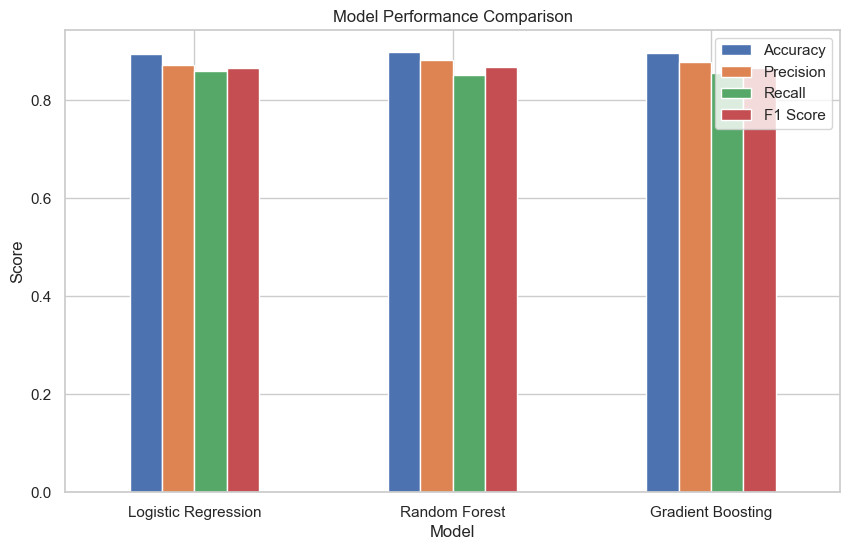

In [54]:
results.set_index("Model").plot(kind="bar", figsize=(10,6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()